# Statistical Inference

This notebook demonstrates practical examples of:

- Type I and Type II Errors
- Conditional Probability
- Bayes' Theorem
- Bayes' Theorem in Machine Learning
- Point Estimates
- Confidence Intervals
- Margin of Error
- Z-Based Confidence Intervals
- t-Based Confidence Intervals

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Type I and Type II Errors

A hypothesis test can produce four possible outcomes depending on:

1. Whether $H_0$ is actually true or false.
2. Whether we reject or fail to reject $H_0$.

In [2]:
outcomes = [
    ["True", "Reject H₀", "Type I Error"],
    ["True", "Fail to reject H₀", "Correct"],
    ["False", "Reject H₀", "Correct"],
    ["False", "Fail to reject H₀", "Type II Error"]
]

print(f"{'Reality':<15}{'Decision':<22}{'Outcome'}")
print("-" * 60)

for reality, decision, outcome in outcomes:
    print(f"{reality:<15}{decision:<22}{outcome}")

Reality        Decision              Outcome
------------------------------------------------------------
True           Reject H₀             Type I Error
True           Fail to reject H₀     Correct
False          Reject H₀             Correct
False          Fail to reject H₀     Type II Error


### Easy Way to Remember

**Type I Error**

$$
\text{True }H_0 \rightarrow \text{Reject }H_0
$$

**Type II Error**

$$
\text{False }H_0 \rightarrow \text{Fail to reject }H_0
$$

# Bayesian Statistics

Bayesian statistics uses probability to reason about an event given
information about another event.

Before applying Bayes' theorem, we first understand:

- Independent events
- Dependent events
- Conditional probability

In [3]:
# Independent coin tosses

p_head_first = 0.5
p_head_second = 0.5

p_both_heads = p_head_first * p_head_second

print("P(Head on first toss):", p_head_first)
print("P(Head on second toss):", p_head_second)
print("P(Both tosses are Heads):", p_both_heads)

P(Head on first toss): 0.5
P(Head on second toss): 0.5
P(Both tosses are Heads): 0.25


# Dependent Events — Marble Example

A bag contains:

- 3 yellow marbles
- 2 red marbles

Total = 5

The first event is selecting a red marble.

If the red marble is not replaced, the probability of selecting yellow
changes for the second draw.

In [4]:
# First draw: Red marble
p_red = 2 / 5

# After drawing a red marble without replacement:
# 3 yellow marbles remain out of 4 total marbles.
p_yellow_given_red = 3 / 4

# Probability of Red followed by Yellow
p_red_and_yellow = p_red * p_yellow_given_red

print("P(Red):", p_red)
print("P(Yellow | Red):", p_yellow_given_red)
print("P(Red ∩ Yellow):", p_red_and_yellow)

P(Red): 0.4
P(Yellow | Red): 0.75
P(Red ∩ Yellow): 0.30000000000000004


# Bayes' Theorem

Bayes' theorem is:

$$
P(B|A)=
\frac{P(B)P(A|B)}{P(A)}
$$

It allows us to calculate a conditional probability using related
probabilities.

In [5]:
# Example values
p_b = 0.4
p_a_given_b = 0.75
p_a = 0.5

p_b_given_a = (p_b * p_a_given_b) / p_a

print("P(B | A) =", p_b_given_a)

P(B | A) = 0.6000000000000001


# Bayes' Theorem — General Form

The equivalent form is:

$$
P(A|B)=
\frac{P(A)P(B|A)}{P(B)}
$$

The form we use depends on which conditional probability we want to
calculate.

# Bayes' Theorem in Machine Learning

Suppose a dataset contains:

- $X_1$ = Size of house
- $X_2$ = Number of rooms
- $X_3$ = Location
- $Y$ = Price

We can reason about:

$$
P(Y|X_1,X_2,X_3)
$$

Using Bayes' theorem:

$$
P(Y|X_1,X_2,X_3)
=
\frac{
P(Y)P(X_1,X_2,X_3|Y)
}{
P(X_1,X_2,X_3)
}
$$

This mathematical idea forms part of the foundation of the **Naive Bayes**
algorithm.

# Point Estimate

A point estimate is a single value used to estimate an unknown population
parameter.

For the population mean:

$$
\bar{x}=\text{Point Estimate}
$$

In [6]:
sample = np.array([2.1, 2.4, 2.6, 2.8, 3.0])

point_estimate = np.mean(sample)

print("Sample:", sample)
print("Point estimate (sample mean):", point_estimate)

Sample: [2.1 2.4 2.6 2.8 3. ]
Point estimate (sample mean): 2.5799999999999996


# Confidence Interval

A confidence interval provides a range around the point estimate.

General form:

$$
CI=
\text{Point Estimate}
\pm
\text{Margin of Error}
$$

For the population mean:

$$
CI=
\bar{x}
\pm
\text{Margin of Error}
$$

# Margin of Error

For a Z-based confidence interval:

$$
ME=
Z_{\alpha/2}
\frac{\sigma}{\sqrt{n}}
$$

Therefore:

$$
CI=
\bar{x}
\pm
Z_{\alpha/2}
\frac{\sigma}{\sqrt{n}}
$$

# CAT Exam Scores — 95% Confidence Interval

### Given

- Population standard deviation: $\sigma=100$
- Sample size: $n=25$
- Sample mean: $\bar{x}=520$
- Confidence level: $95\%$

Since the population standard deviation is known, we use a Z-based
confidence interval.

In [9]:
# Given values
sigma = 100
n = 25
sample_mean = 520
confidence_level = 0.95

# Significance level
alpha = 1 - confidence_level

# Critical Z-value for a two-sided 95% confidence interval
z_critical = stats.norm.ppf(1 - alpha / 2)

print("Alpha:", alpha)
print("Critical Z-value:", z_critical)

Alpha: 0.050000000000000044
Critical Z-value: 1.959963984540054


In [10]:
# Calculate the margin of error

margin_of_error = z_critical * (sigma / np.sqrt(n))

print("Margin of Error:", margin_of_error)

Margin of Error: 39.19927969080108


In [11]:
# Calculate confidence interval

lower_limit = sample_mean - margin_of_error
upper_limit = sample_mean + margin_of_error

print("Lower Confidence Limit:", lower_limit)
print("Upper Confidence Limit:", upper_limit)
print(f"95% Confidence Interval: [{lower_limit:.1f}, {upper_limit:.1f}]")

Lower Confidence Limit: 480.80072030919894
Upper Confidence Limit: 559.1992796908011
95% Confidence Interval: [480.8, 559.2]


### Interpretation

The calculated 95% confidence interval is:

$$
[480.8,\;559.2]
$$

The margin of error is:

$$
39.2
$$

Therefore:

$$
520\pm39.2
$$

gives:

$$
480.8\leq\mu\leq559.2
$$

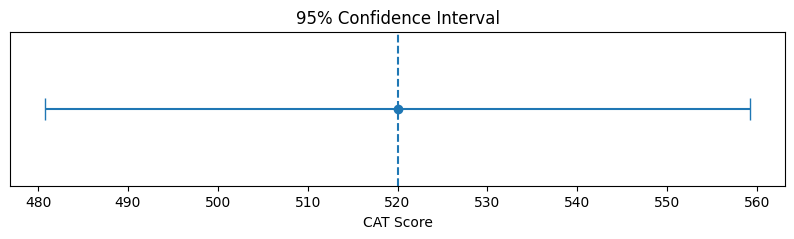

In [12]:
plt.figure(figsize=(10, 2))

plt.errorbar(
    sample_mean,
    0,
    xerr=margin_of_error,
    fmt='o',
    capsize=8
)

plt.axvline(sample_mean, linestyle='--')

plt.yticks([])
plt.xlabel("CAT Score")
plt.title("95% Confidence Interval")

plt.show()

# t-Based Confidence Interval

When the population standard deviation is unknown, the sample standard
deviation $s$ is used.

The confidence interval is:

$$
CI=
\bar{x}
\pm
t_{\alpha/2}
\frac{s}{\sqrt{n}}
$$

Degrees of freedom:

$$
df=n-1
$$

In [13]:
# Example t-based confidence interval

sample_data = np.array([
    68, 72, 70, 71, 69,
    73, 75, 67, 70, 74
])

n = len(sample_data)
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1)

confidence_level = 0.95
alpha = 1 - confidence_level
df = n - 1

t_critical = stats.t.ppf(1 - alpha / 2, df)

margin_of_error = t_critical * (sample_std / np.sqrt(n))

lower_limit = sample_mean - margin_of_error
upper_limit = sample_mean + margin_of_error

print("Sample size:", n)
print("Sample mean:", sample_mean)
print("Sample standard deviation:", sample_std)
print("Degrees of freedom:", df)
print("Critical t-value:", t_critical)
print("Margin of Error:", margin_of_error)
print("Confidence Interval:", (lower_limit, upper_limit))

Sample size: 10
Sample mean: 70.9
Sample standard deviation: 2.6012817353502227
Degrees of freedom: 9
Critical t-value: 2.262157162798205
Margin of Error: 1.8608448537581366
Confidence Interval: (np.float64(69.03915514624187), np.float64(72.76084485375814))


# Z-Based vs t-Based Confidence Intervals

### Z-Based

Used when the population standard deviation $\sigma$ is known:

$$
CI=
\bar{x}
\pm
Z_{\alpha/2}
\frac{\sigma}{\sqrt{n}}
$$

### t-Based

Used when the population standard deviation is unknown and the sample
standard deviation $s$ is used:

$$
CI=
\bar{x}
\pm
t_{\alpha/2}
\frac{s}{\sqrt{n}}
$$

For the t-based interval:

$$
df=n-1
$$

# Final Summary

### Type I Error

$$
\text{True }H_0 \rightarrow \text{Reject }H_0
$$

### Type II Error

$$
\text{False }H_0 \rightarrow \text{Fail to reject }H_0
$$

### Bayes' Theorem

$$
P(B|A)=
\frac{P(B)P(A|B)}{P(A)}
$$

### Point Estimate

$$
\bar{x}
$$

### Confidence Interval

$$
CI=
\text{Point Estimate}
\pm
\text{Margin of Error}
$$

### Z-Based Margin of Error

$$
ME=
Z_{\alpha/2}
\frac{\sigma}{\sqrt{n}}
$$

### t-Based Margin of Error

$$
ME=
t_{\alpha/2}
\frac{s}{\sqrt{n}}
$$

### Overall Idea

$$
\boxed{
\text{Sample Data}
\rightarrow
\text{Inference}
\rightarrow
\text{Decision / Uncertainty}
}
$$

These concepts provide an important foundation for statistical reasoning
in Data Science and Machine Learning.